Generating presentation graphs...
Accuracy chart generated!
Clean token efficiency chart generated!
Done! Check your folder for the PNG files.


/var/folders/8s/4m_yv1j56clbvl9kr6v3styc0000gn/T/ipykernel_58349/1923817033.py:224: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, fontsize=11, fontweight='bold')


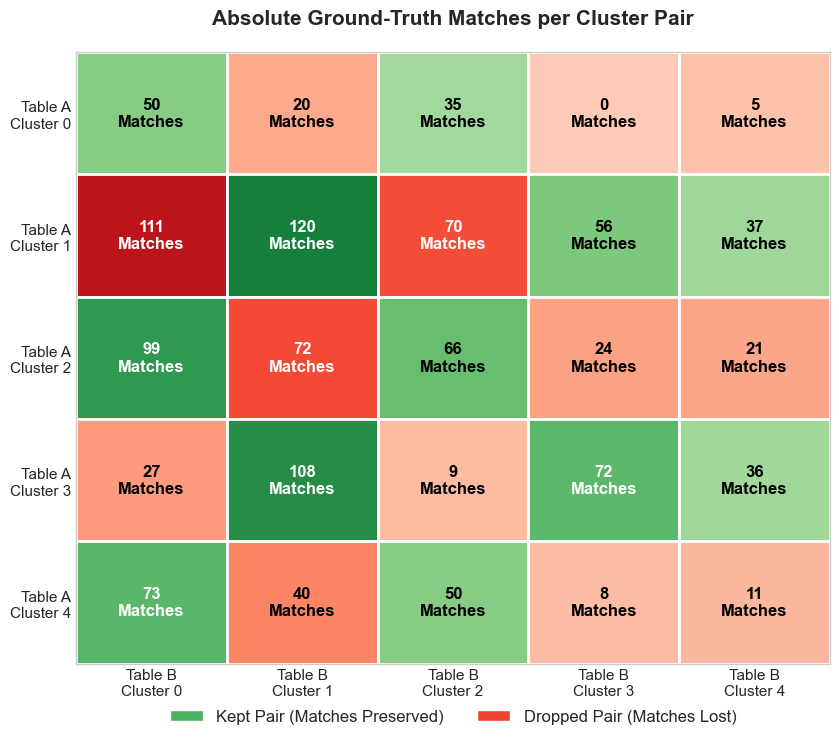

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import numpy as np

# Set a clean, professional style for presentations
plt.style.use('seaborn-v0_8-whitegrid')

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

def plot_block_size_tuning():
    sizes = ['5x5', '10x10', '15x15', '20x20', '25x25']
    f1_scores = [50.72, 57.10, 55.15, 47.96, 48.54]
    tokens_per_pair = [1211/25, 2321/100, 3433/225, 4549/400, 5807/625]
    
    fig, ax1 = plt.subplots(figsize=(9, 5))
    
    # --- Left Axis: F1-Score ---
    ax1.plot(sizes, f1_scores, marker='o', linestyle='-', color='#1f77b4', 
             linewidth=3, markersize=8, label='F1-Score (%)')
    ax1.set_xlabel('Block Size', fontsize=12, fontweight='bold')
    ax1.set_ylabel('F1-Score (%)', fontsize=12, color='#1f77b4', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    
    # Set to 6 divisions: 40, 45, 50, 55, 60, 65
    ax1.set_ylim(40, 65)
    ax1.set_yticks(np.linspace(40, 65, 6))

    # --- Right Axis: Token Cost ---
    ax2 = ax1.twinx()
    ax2.plot(sizes, tokens_per_pair, marker='D', linestyle='--', color='#d62728', 
             linewidth=3, label='Tokens per Pair')
    ax2.set_ylabel('Tokens per Comparison', fontsize=12, color='#d62728', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#d62728')
    
    # Set to 6 divisions to match ax1: 0, 10, 20, 30, 40, 50
    ax2.set_ylim(0, 50)
    ax2.set_yticks(np.linspace(0, 50, 6))

    # Force the grid to align by using only one axis' grid
    ax1.grid(True, axis='y', linestyle='-', alpha=0.7)
    ax2.grid(False) # Turn off the second grid so they don't overlap awkwardly
    
    # Combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower center', 
               bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=11)
    
    plt.title('Block Size Tuning: Accuracy vs. Efficiency', fontsize=14, pad=20, fontweight='bold')
    plt.tight_layout()
    plt.savefig('1_block_size_tuning_aligned.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_clustering_purity():
    # Data extracted from your DistilBERT evaluation logs
    clusters = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']
    
    # Table A Data
    a_pos = np.array([5, 9, 9, 0, 7])
    a_neg = np.array([0, 7, 3, 9, 1])
    a_purity = [100.0, 56.25, 75.0, 100.0, 87.5]
    
    # Table B Data
    b_pos = np.array([10, 4, 7, 0, 1])
    b_neg = np.array([3, 12, 1, 8, 4])
    b_purity = [76.92, 75.0, 87.5, 100.0, 80.0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    
    # Colors matching standard sentiment (Green for Positive, Red/Orange for Negative)
    color_pos = '#2ca02c' 
    color_neg = '#d62728'

    # --- Plot Table A ---
    ax1.bar(clusters, a_pos, label='Positive Reviews', color=color_pos, edgecolor='white')
    ax1.bar(clusters, a_neg, bottom=a_pos, label='Negative Reviews', color=color_neg, edgecolor='white')
    ax1.set_title('Table A: Cluster Composition & Purity', fontsize=13, pad=15)
    ax1.set_ylabel('Number of Reviews (Cluster Size)', fontsize=12)
    ax1.tick_params(axis='x', rotation=25)
    
    # Add purity labels on top of Table A bars
    for i in range(len(clusters)):
        total_height = a_pos[i] + a_neg[i]
        ax1.text(i, total_height + 0.3, f'{a_purity[i]:.1f}%', ha='center', fontweight='bold', fontsize=10)

    # --- Plot Table B ---
    ax2.bar(clusters, b_pos, label='Positive Reviews', color=color_pos, edgecolor='white')
    ax2.bar(clusters, b_neg, bottom=b_pos, label='Negative Reviews', color=color_neg, edgecolor='white')
    ax2.set_title('Table B: Cluster Composition & Purity', fontsize=13, pad=15)
    ax2.tick_params(axis='x', rotation=25)
    
    # Add purity labels on top of Table B bars
    for i in range(len(clusters)):
        total_height = b_pos[i] + b_neg[i]
        ax2.text(i, total_height + 0.3, f'{b_purity[i]:.1f}%', ha='center', fontweight='bold', fontsize=10)

    # Add a single legend for both subplots
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=12)

    plt.suptitle('DistilBERT Clustering: Row Distribution and Purity', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('2_cluster_purity_composition.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_absolute_matches_heatmap():
    # True composition of clusters
    A_pos = [5, 9, 9, 0, 7]
    A_neg = [0, 7, 3, 9, 1]
    B_pos = [10, 4, 7, 0, 1]
    B_neg = [3, 12, 1, 8, 4]

    # Your LLM filter logic
    kept_pairs = [(2,2), (2,0), (1,4), (1,1), (1,3), (4,2), (4,0), (0,2), (0,0), (3,4), (3,1), (3,3)]

    # Calculate actual matches: (A_pos * B_pos) + (A_neg * B_neg)
    matches_matrix = np.zeros((5, 5), dtype=int)
    for i in range(5):
        for j in range(5):
            matches_matrix[i, j] = A_pos[i]*B_pos[j] + A_neg[i]*B_neg[j]

    fig, ax = plt.subplots(figsize=(8.5, 7.5))
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(4.5, -0.5)

    max_kept = max([matches_matrix[i, j] for i in range(5) for j in range(5) if (i, j) in kept_pairs])
    max_dropped = max([matches_matrix[i, j] for i in range(5) for j in range(5) if (i, j) not in kept_pairs])

    cmap_kept = plt.cm.Greens
    cmap_dropped = plt.cm.Reds

    # Draw colored rectangles and text
    for i in range(5):
        for j in range(5):
            val = matches_matrix[i, j]
            is_kept = (i, j) in kept_pairs
            
            if is_kept:
                # Scale color intensity
                norm_val = 0.2 + 0.6 * (val / max(max_kept, 1))
                color = cmap_kept(norm_val)
            else:
                norm_val = 0.2 + 0.6 * (val / max(max_dropped, 1))
                color = cmap_dropped(norm_val)
                
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, facecolor=color, edgecolor='white', linewidth=2)
            ax.add_patch(rect)
            
            # Contrast text color for readability
            text_color = 'white' if norm_val > 0.55 else 'black'
            ax.text(j, i, f"{val}\nMatches", ha='center', va='center', color=text_color, fontweight='bold', fontsize=12)

    # Grid labels
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels([f"Table B\nCluster {j}" for j in range(5)], fontsize=11)
    ax.set_yticklabels([f"Table A\nCluster {i}" for i in range(5)], fontsize=11)

    # Clean Legend
    legend_elements = [
        Patch(facecolor=cmap_kept(0.6), edgecolor='white', label='Kept Pair (Matches Preserved)'),
        Patch(facecolor=cmap_dropped(0.6), edgecolor='white', label='Dropped Pair (Matches Lost)')
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=12)

    plt.title('Absolute Ground-Truth Matches per Cluster Pair', pad=20, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('3_cluster_matches_heatmap.png', dpi=300, bbox_inches='tight')

def plot_final_performance():
    labels = ['Naive Baseline', 'Block Join\n(10x10)', 'Cluster Join\n(Filtered)', 'Cluster Join\n(Adjusted)*']
    recall = [21.16, 51.15, 34.59, 52.62]
    precision = [69.17, 79.49, 82.58, 82.58]
    f1 = [28.64, 62.24, 48.76, 64.28]
    
    x = np.arange(len(labels))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.bar(x - width, recall, width, label='Recall', color='#1f77b4', edgecolor='white')
    ax.bar(x, precision, width, label='Precision', color='#ff7f0e', edgecolor='white')
    ax.bar(x + width, f1, width, label='F1-Score', color='#2ca02c', edgecolor='white')
    
    ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    ax.set_title('Pipeline Accuracy Comparison', fontsize=15, pad=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
    
    # Add frequent horizontal lines (every 10%)
    ax.set_yticks(np.arange(0, 101, 10))
    ax.grid(axis='y', linestyle='-', alpha=0.7)
    ax.grid(axis='x', visible=False) # FIXED: changed b=False to visible=False
    
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=11)
    ax.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig('4_final_accuracy_aligned.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Accuracy chart generated!")

def plot_efficiency_tokens_only():
    methods = ['Naive Baseline', 'Block Join\n(10x10)', 'Cluster Join\n(Filtered)']
    tokens = [581150, 57094, 35441] 
    
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # --- Tokens Chart ---
    ax.bar(methods, tokens, color=['#7f7f7f', '#1f77b4', '#2ca02c'], width=0.5, edgecolor='white')
    ax.set_title('Total Tokens Used (Log Scale)', fontsize=15, pad=15, fontweight='bold')
    ax.set_ylabel('Tokens', fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.set_ylim(10000, 3000000) 
    
    # Standard major grid lines only (removed the minor "trippy" lines)
    ax.grid(which='major', axis='y', linestyle='-', alpha=0.7)
    ax.grid(axis='x', visible=False)
    ax.set_xticklabels(methods, fontsize=11, fontweight='bold')
    
    for i, v in enumerate(tokens):
        ax.text(i, v * 1.3, f'{v:,}', ha='center', fontweight='bold', fontsize=12)
        
    plt.tight_layout()
    plt.savefig('5_pipeline_efficiency_tokens_clean.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Clean token efficiency chart generated!")

if __name__ == '__main__':
    print("Generating presentation graphs...")
    plot_block_size_tuning()
    plot_clustering_purity()
    plot_absolute_matches_heatmap()
    plot_final_performance()
    plot_efficiency_tokens_only()
    print("Done! Check your folder for the PNG files.")